# Benchmark PASTS on the Corporación Favorita dataset

Dataset: https://www.kaggle.com/c/favorita-grocery-sales-forecasting  
Expected location: `data/favorita-grocery-sales-forecasting/`

This notebook tests PASTS at three aggregation levels covering very different time-series profiles:

1. **Store level** (54 series) — smooth, high-volume daily sales
2. **Family × Store** (~1 800 series) — mid-level hierarchy, mixed volumes
3. **Curated items** — hand-picked profiles:
   - high-rotation grocery item
   - low-volume / intermittent item
   - product launched mid-dataset (cold start)
4. **Scale test** — 50 random items in parallel

In [ ]:
import os
import time
import warnings

import numpy as np
import pandas as pd
from darts.models import RandomForestModel
from matplotlib import pyplot as plt

from pasts.signal import Signal
from pasts.components import LinearTrend
from pasts.components.aggregated_model import AggregatedModel

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)

Support for PyTorch based likelihood models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
Support for Torch based models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
c:\Users\Vincent LAURENT\PROJETS\CURRENT\pasts\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def _make_daily_index(df: pd.DataFrame) -> pd.DataFrame:
    """Reindex a DataFrame with a complete daily DatetimeIndex, filling gaps with 0."""
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq="D")
    return df.reindex(full_idx, fill_value=0)

## 0. Load data

In [ ]:
DATA_DIR = os.path.join("..", "..", "data", "favorita-grocery-sales-forecasting")
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
ITEMS_PATH = os.path.join(DATA_DIR, "items.csv")
STORES_PATH = os.path.join(DATA_DIR, "stores.csv")
OUTPUT_DIR = os.path.join(DATA_DIR, "favorita_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Metadata
items = pd.read_csv(ITEMS_PATH)
stores = pd.read_csv(STORES_PATH)
print(f"{len(items)} items, {len(stores)} stores")

4100 items, 54 stores


In [ ]:
# Load train file (may take a few minutes)
t0 = time.time()

dtypes = {
    "id": "int32",
    "store_nbr": "int16",
    "item_nbr": "int32",
    "unit_sales": "float32",
    "onpromotion": "object",
}
train = pd.read_csv(TRAIN_PATH, dtype=dtypes, parse_dates=["date"], nrows=10_000_000)
train["unit_sales"] = train["unit_sales"].clip(lower=0)

print(f"Loaded {len(train):,} rows in {time.time() - t0:.0f}s")

# Merge metadata
train = train.merge(items[["item_nbr", "family", "perishable"]], on="item_nbr")
train = train.merge(stores[["store_nbr", "city", "state", "type"]], on="store_nbr")

Loaded 10,000,000 rows in 4s


---
## Scenario 1 — Store-level aggregation (54 series)

Aggregate sales by store and day, then select 6 diverse stores.

Shape: (233, 5)


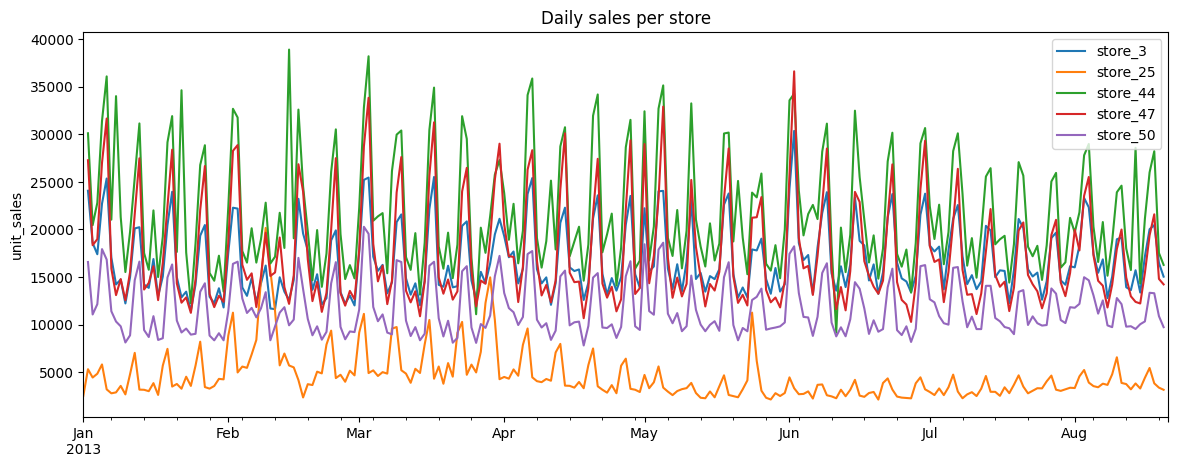

In [ ]:
df_store = (
    train.groupby(["date", "store_nbr"])["unit_sales"]
    .sum()
    .unstack("store_nbr")
    .sort_index()
)
df_store.columns = [f"store_{c}" for c in df_store.columns]
df_store = _make_daily_index(df_store)

stores_sample = ["store_3", "store_25", "store_44", "store_47", "store_50", "store_53"]
stores_sample = [s for s in stores_sample if s in df_store.columns]
df = df_store[stores_sample].copy()

print(f"Shape: {df.shape}")
df.plot(title="Daily sales per store")
plt.ylabel("unit_sales")
plt.show()

In [ ]:
signal_store = Signal(df, path=os.path.join(OUTPUT_DIR, "store_level"))
signal_store.handle_nan("interpolate")  

# Statistical tests
signal_store.stat.test_stationarity()

,statistic,p_value,n_lags,n_obs,stationary
store_3,-2.472894,0.122210,15,217,False
store_25,-2.102762,0.243406,15,217,False
store_44,-4.094353,0.000990,13,219,True
store_47,-3.236138,0.017986,14,218,True
store_50,-4.920813,0.000032,15,217,True


In [ ]:
# Validation split: last 60 days as test
timestamp = str(df.index[-1] - pd.Timedelta(days=60))[:10]
signal_store.validation_split(timestamp=timestamp)
print(f"Split at {timestamp}")

# Decomposition: remove linear trend
signal_store.decompose()
signal_store.residual -= LinearTrend().fit(signal_store.data.dropna())

Split at 2013-06-22


In [ ]:
print("Fitting RandomForest ...")
signal_store.apply_model(RandomForestModel(lags=30))

Fitting RandomForest ...


In [ ]:
# Scores
signal_store.compute_scores()
for metric, df_score in signal_store.performance_models.get("unit_wise", {}).items():
    print(f"{metric}:")
    display(df_score)

r2:


,RandomForestModel
store_3,0.751483
store_25,-1.049936
store_44,0.664088
store_47,0.674431
store_50,0.687679


mse:


,RandomForestModel
store_3,2680679.219108
store_25,1595376.570727
store_44,9639866.785018
store_47,8474041.195223
store_50,1961145.948065


rmse:


...

,RandomForestModel
store_3,7.479604
store_25,35.424188
store_44,11.666506
store_47,12.288309
store_50,8.714122


smape:


,RandomForestModel
store_3,7.457801
store_25,29.028004
store_44,11.059599
store_47,11.474412
store_50,8.535965


mae:


,RandomForestModel
store_3,1297.063541
store_25,1152.85818
store_44,2409.7465
store_47,2090.932725
store_50,1046.45249


In [ ]:
# Aggregated model
signal_store.apply_model(AggregatedModel(
    {"RandomForest": RandomForestModel(lags=30)},
))
signal_store.compute_scores(axis=1)
signal_store.compute_conf_intervals()

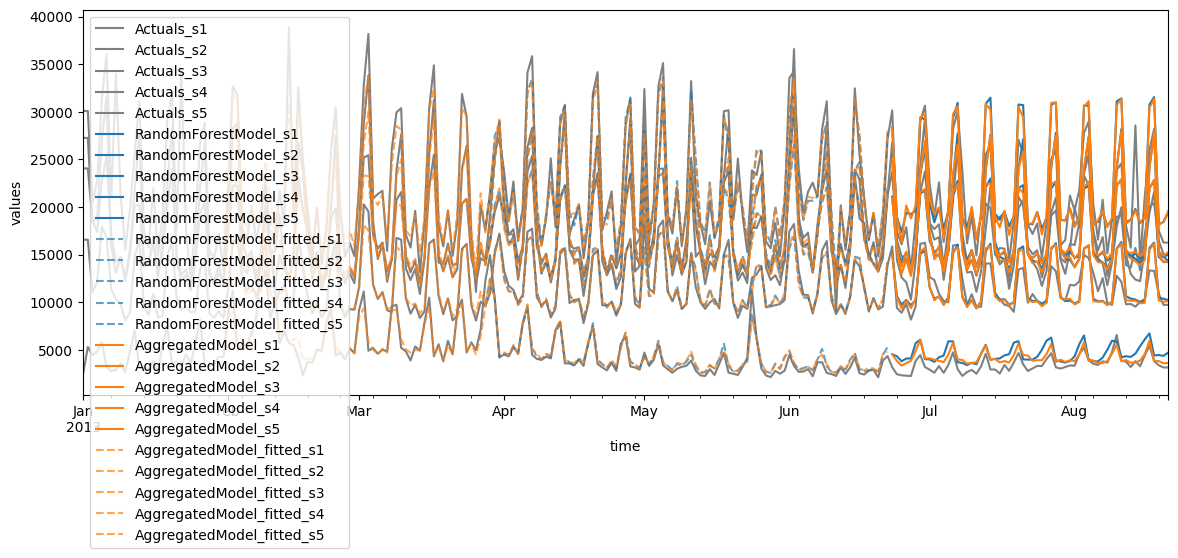

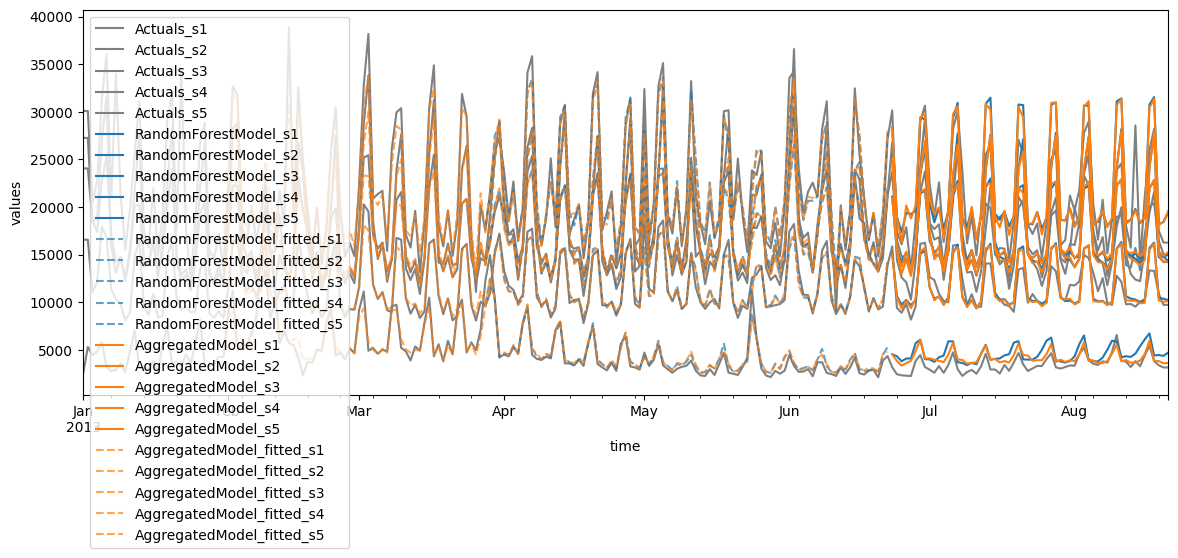

In [ ]:
# Forecast
signal_store.forecast("AggregatedModel", horizon=100)
signal_store.compute_conf_intervals()

signal_store.plot.predictions(show_fitted=True)



---
## Scenario 2 — Family × Store (single store, all families)

Pick one high-volume store (store 44) and aggregate by product family. Keep the top 6 families by total volume.

Store 44: 22 product families total
Selected: ['GROCERY I', 'BEVERAGES', 'CLEANING', 'DAIRY', 'BREAD/BAKERY', 'MEATS']
Shape: (231, 6)


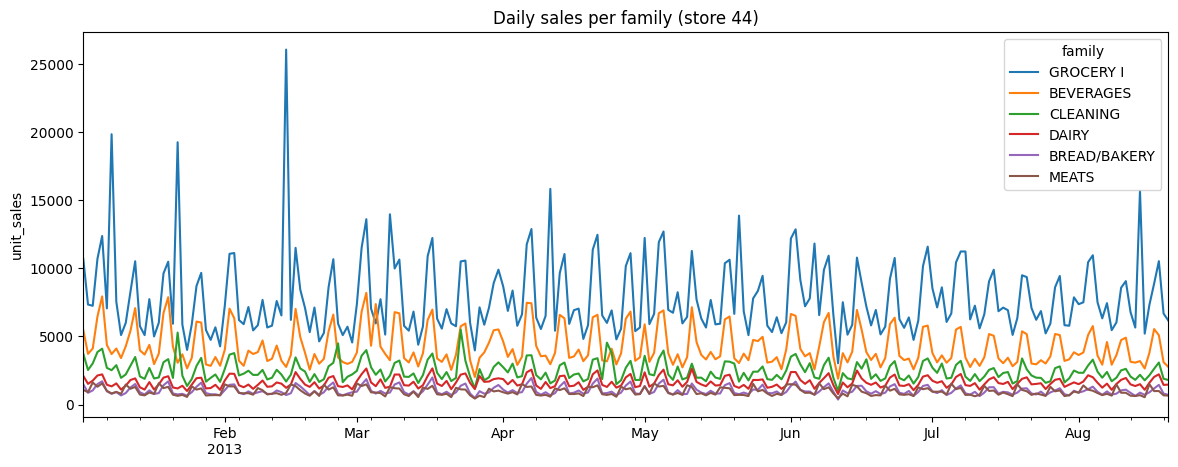

In [ ]:
store_id = 44
df_family = (
    train[train["store_nbr"] == store_id]
    .groupby(["date", "family"])["unit_sales"]
    .sum()
    .unstack("family")
    .sort_index()
)
df_family = _make_daily_index(df_family)

top_families = df_family.sum().nlargest(6).index.tolist()
df = df_family[top_families].copy()

print(f"Store {store_id}: {df_family.shape[1]} product families total")
print(f"Selected: {top_families}")
print(f"Shape: {df.shape}")

df.plot(title=f"Daily sales per family (store {store_id})")
plt.ylabel("unit_sales")
plt.show()

In [ ]:
signal_family = Signal(df, path=os.path.join(OUTPUT_DIR, "family_store"))

timestamp = str(df.index[-1] - pd.Timedelta(days=60))[:10]
print(f"Split at {timestamp}")
signal_family.validation_split(timestamp=timestamp)

# Decomposition
signal_family.decompose()
signal_family.residual -= LinearTrend().fit(signal_family.data)

Split at 2013-06-21


In [ ]:

print("Fitting RandomForest ...")
signal_family.apply_model(RandomForestModel(lags=14))

Fitting RandomForest ...


In [ ]:
signal_family.compute_scores()
for metric, df_score in signal_family.performance_models.get("unit_wise", {}).items():
    print(f"{metric}:")
    display(df_score)

r2:


,RandomForestModel
GROCERY I,0.297036
BEVERAGES,0.77609
CLEANING,0.63911
DAIRY,0.806247
BREAD/BAKERY,0.695625
MEATS,0.692517


mse:


,RandomForestModel
GROCERY I,3589932.667795
BEVERAGES,423090.901313
CLEANING,107421.350312
DAIRY,26871.62833
BREAD/BAKERY,30093.25743
MEATS,20920.305768


rmse:


...

,RandomForestModel
GROCERY I,13.20389
BEVERAGES,11.359152
CLEANING,11.294222
DAIRY,7.574916
BREAD/BAKERY,12.1351
MEATS,12.695992


smape:


,RandomForestModel
GROCERY I,12.997739
BEVERAGES,10.579612
CLEANING,10.743543
DAIRY,7.416566
BREAD/BAKERY,11.145417
MEATS,12.165167


mae:


,RandomForestModel
GROCERY I,1077.199833
BEVERAGES,478.361
CLEANING,254.777167
DAIRY,121.966333
BREAD/BAKERY,121.625593
MEATS,114.549596


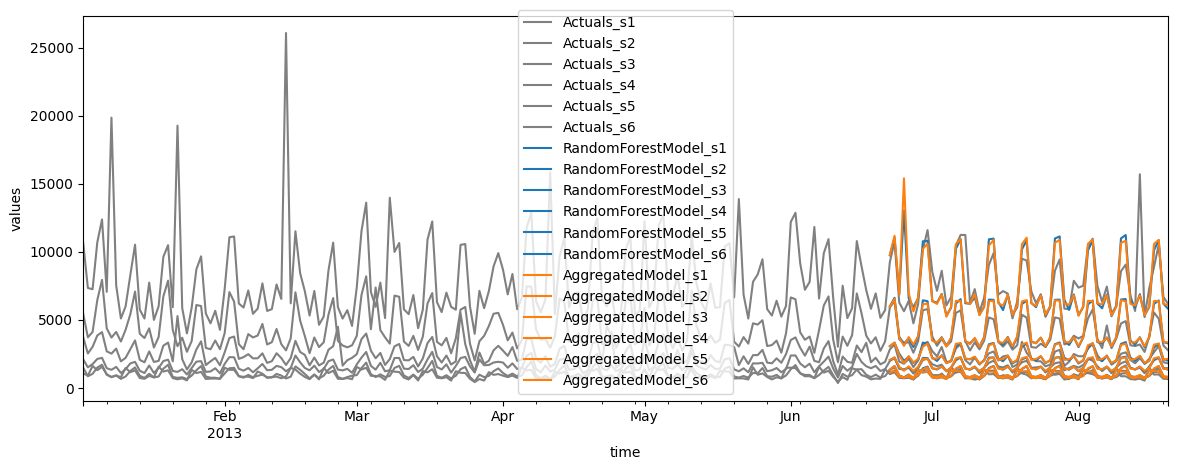

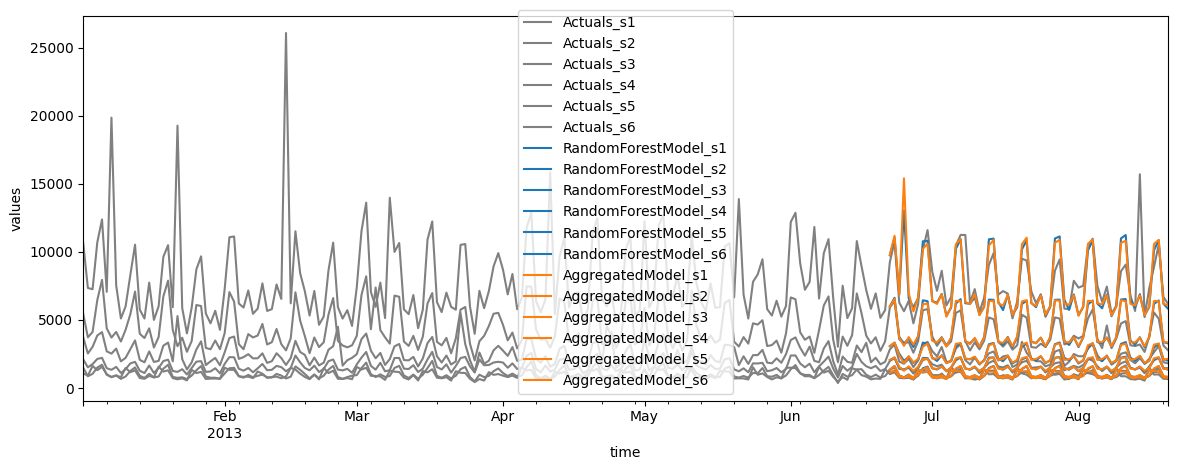

In [ ]:
signal_family.apply_model(AggregatedModel(
    {"RandomForest": RandomForestModel(lags=14)},
))
signal_family.compute_scores(axis=1)
signal_family.compute_conf_intervals()

signal_family.plot.predictions()

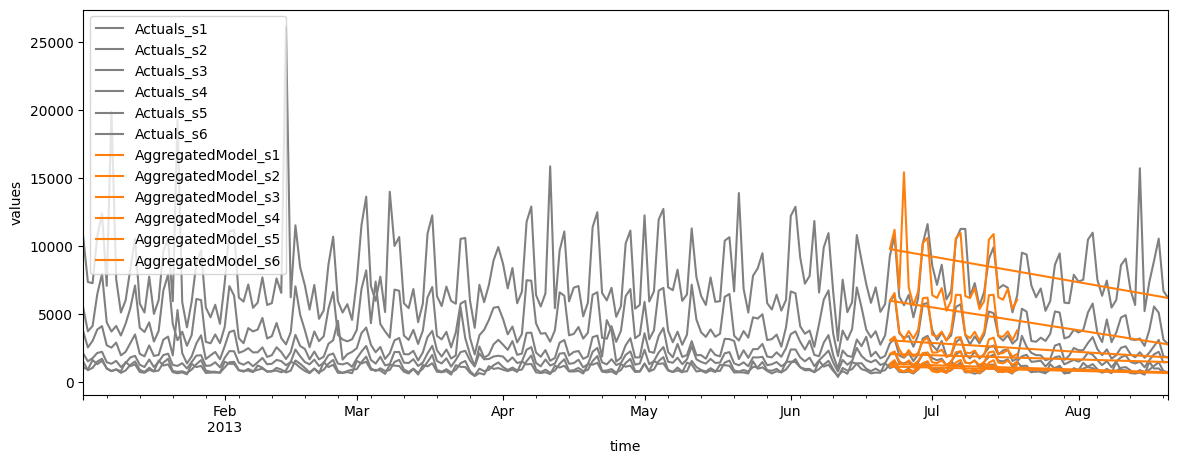

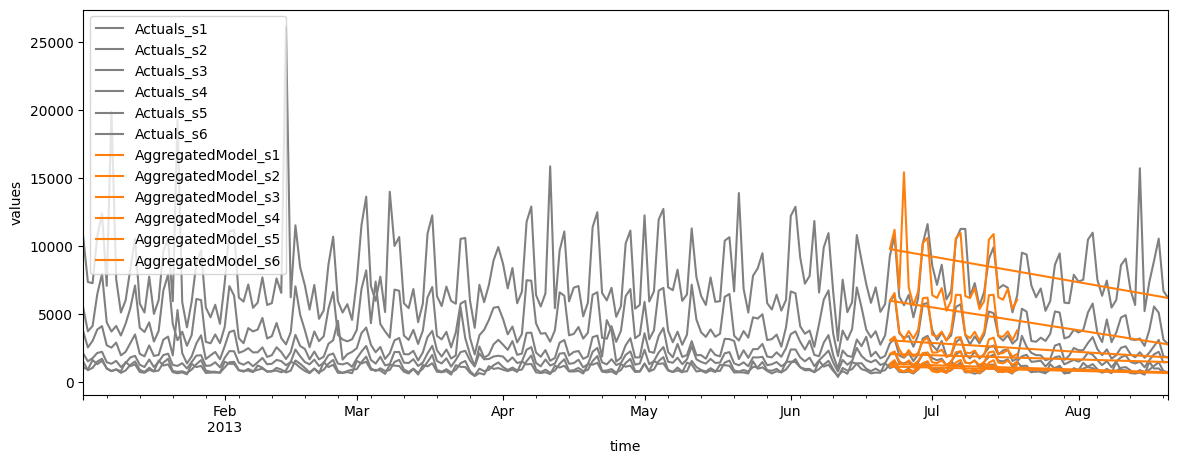

In [ ]:
signal_family.forecast("AggregatedModel", horizon=28)
signal_family.compute_conf_intervals()

signal_family.plot.forecast()

---
## Scenario 3 — Curated individual items (diverse profiles)

Select 3 items with contrasting profiles:
- **High-volume**: top seller
- **Low-volume**: intermittent item (>50% zero days)
- **Cold start**: product launched mid-dataset

In [ ]:
store_id = 44

df_items = train[train["store_nbr"] == store_id].copy()
df_items_pivot = (
    df_items.groupby(["date", "item_nbr"])["unit_sales"]
    .sum()
    .unstack("item_nbr")
    .sort_index()
)
df_items_pivot = _make_daily_index(df_items_pivot)

total_sales = df_items_pivot.sum()
n_days = len(df_items_pivot)

# Profile 1: high-rotation item (top seller)
high_vol_item = total_sales.idxmax()

# Profile 2: low-volume / intermittent item
zero_pct = (df_items_pivot == 0).sum() / n_days
low_vol_candidates = total_sales[(zero_pct > 0.5) & (total_sales > 10)]
low_vol_item = low_vol_candidates.idxmin() if len(low_vol_candidates) > 0 else total_sales.nsmallest(5).index[-1]

# Profile 3: late launch (cold start)
first_sale = (df_items_pivot > 0).idxmax()
mid_point = df_items_pivot.index[n_days // 2]
late_starters = first_sale[first_sale > mid_point]
if len(late_starters) > 0:
    launch_candidates = total_sales[late_starters.index]
    launch_item = launch_candidates.idxmax()
else:
    launch_item = first_sale.idxmax()

print(f"High-volume: {high_vol_item} (total={total_sales[high_vol_item]:.0f}, zero_pct={zero_pct[high_vol_item]:.1%})")
print(f"Low-volume:  {low_vol_item} (total={total_sales[low_vol_item]:.0f}, zero_pct={zero_pct[low_vol_item]:.1%})")
print(f"Cold start:  {launch_item} (first sale={first_sale[launch_item].date()}, total={total_sales[launch_item]:.0f})")

High-volume: 1047679 (total=109920, zero_pct=0.0%)
Low-volume:  958516 (total=1, zero_pct=0.0%)
Cold start:  1157561 (first sale=2013-06-01, total=3370)


Period: 2013-06-01 -> 2013-08-20 (81 days)


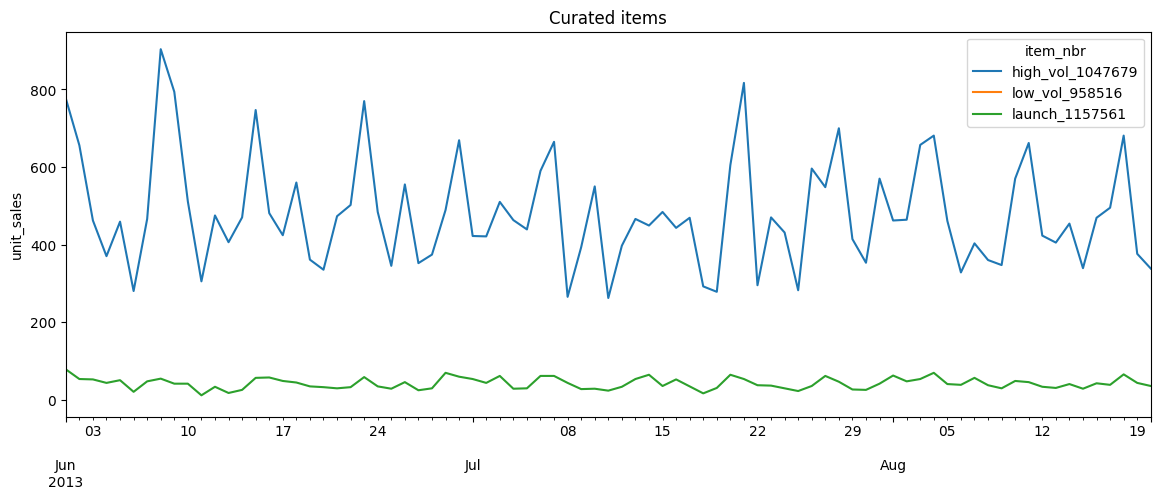

In [ ]:
selected = [high_vol_item, low_vol_item, launch_item]
labels = {
    high_vol_item: f"high_vol_{high_vol_item}",
    low_vol_item: f"low_vol_{low_vol_item}",
    launch_item: f"launch_{launch_item}",
}

df = df_items_pivot[selected].rename(columns=labels).copy()

# Trim to the cold-start product's first sale
launch_col = labels[launch_item]
first_nonzero = df[launch_col][df[launch_col] > 0].index[0]
df = df.loc[first_nonzero:]
print(f"Period: {first_nonzero.date()} -> {df.index[-1].date()} ({len(df)} days)")

df.plot(title="Curated items")
plt.ylabel("unit_sales")
plt.show()

In [ ]:
signal_items = Signal(df, path=os.path.join(OUTPUT_DIR, "curated_items"))
signal_items.handle_nan("interpolate")
print(f"Shape: {signal_items.properties['shape']}")

timestamp = str(df.index[-1] - pd.Timedelta(days=45))[:10]
print(f"Split at {timestamp}")
signal_items.validation_split(timestamp=timestamp)

signal_items.decompose()
signal_items.residual -= LinearTrend().fit(signal_items.data)

Shape: (81, 3)
Split at 2013-07-06


In [ ]:
print("Fitting RandomForest ...")
signal_items.apply_model(RandomForestModel(lags=14))

Fitting RandomForest ...


In [ ]:
signal_items.compute_scores()
for metric, df_score in signal_items.performance_models.get("unit_wise", {}).items():
    print(f"{metric}:")
    display(df_score)

r2:


,RandomForestModel
high_vol_1047679,-3.076529
low_vol_958516,1.0
launch_1157561,-3.684592


mse:


,RandomForestModel
high_vol_1047679,15207.73832
low_vol_958516,0.0
launch_1157561,144.810351


rmse:


...

,RandomForestModel
high_vol_1047679,23.527695
low_vol_958516,0.0
launch_1157561,27.334294


smape:


,RandomForestModel
high_vol_1047679,21.190434
low_vol_958516,0.0
launch_1157561,23.699528


mae:


,RandomForestModel
high_vol_1047679,97.992889
low_vol_958516,0.0
launch_1157561,9.566222


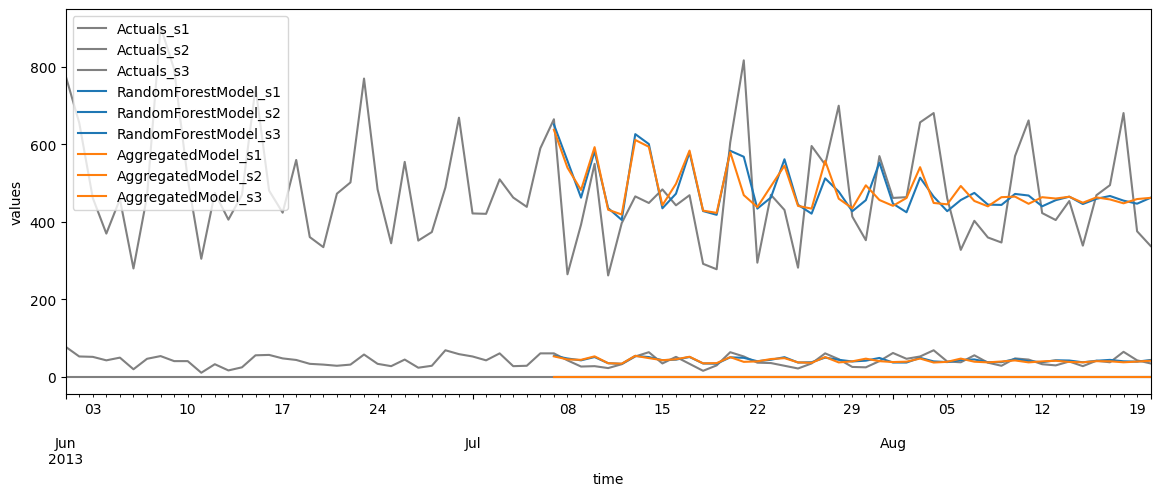

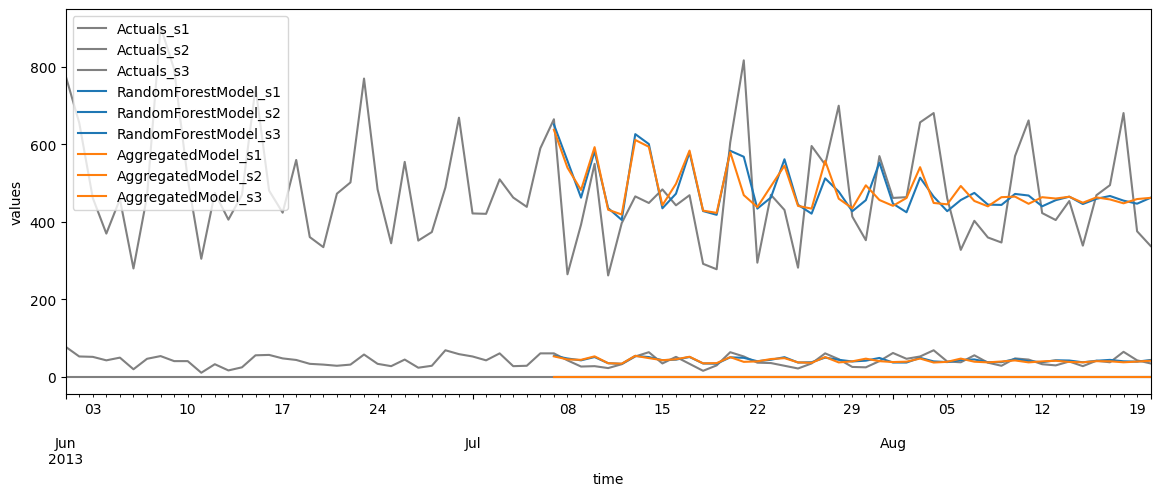

In [ ]:
signal_items.apply_model(AggregatedModel(
    {"RandomForest": RandomForestModel(lags=14)},
))
signal_items.compute_scores(axis=1)
signal_items.compute_conf_intervals()

signal_items.plot.predictions()

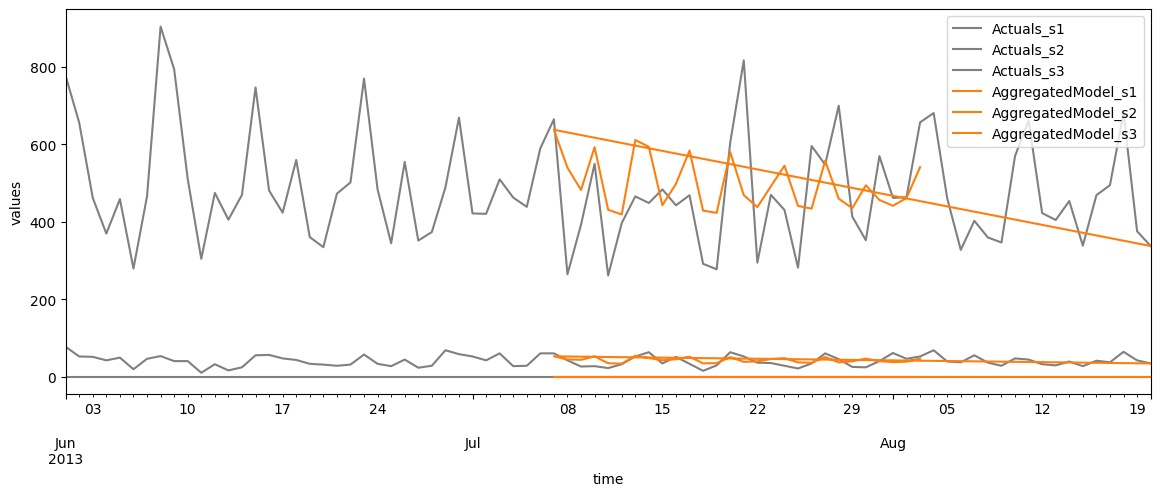

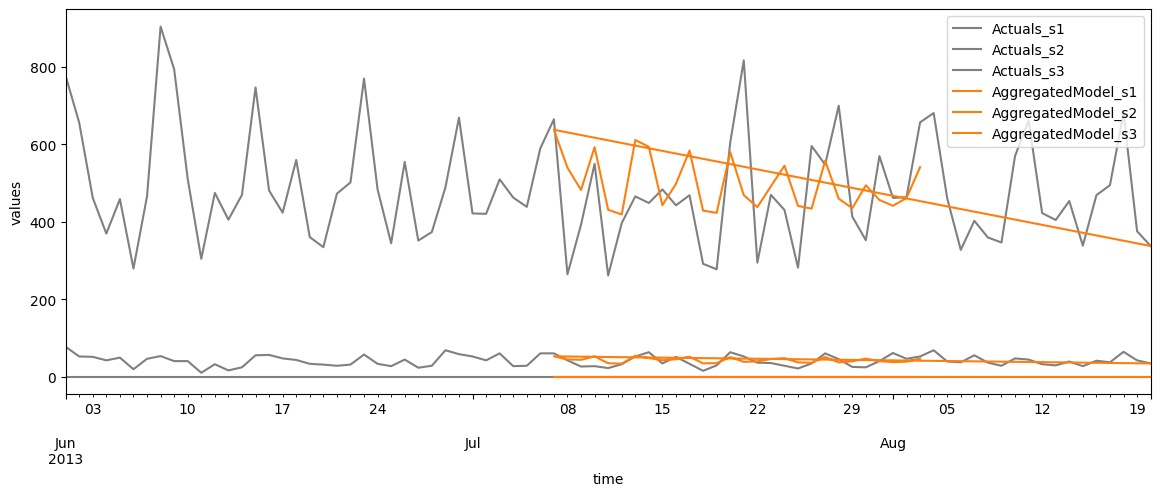

In [ ]:
signal_items.forecast("AggregatedModel", horizon=28)
signal_items.compute_conf_intervals()

signal_items.plot.forecast()

---
## Scenario 4 — Scale test (50 random items)

Draw 50 random items from a single store to stress-test performance with a wide DataFrame.

In [ ]:
N_ITEMS = 50
store_id = 44

df_items_all = train[train["store_nbr"] == store_id].copy()

item_sales = df_items_all.groupby("item_nbr")["unit_sales"].sum()
candidates = item_sales[item_sales > 100].index.tolist()

rng = np.random.default_rng(42)
chosen = rng.choice(candidates, size=min(N_ITEMS, len(candidates)), replace=False)

df_pivot = (
    df_items_all[df_items_all["item_nbr"].isin(chosen)]
    .groupby(["date", "item_nbr"])["unit_sales"]
    .sum()
    .unstack("item_nbr")
    .sort_index()
)
df_pivot.columns = [f"item_{c}" for c in df_pivot.columns]
df_pivot = _make_daily_index(df_pivot)

print(f"Shape: {df_pivot.shape}")

Shape: (231, 50)


In [ ]:
signal_scale = Signal(df_pivot, path=os.path.join(OUTPUT_DIR, "scale_test"))
signal_scale.handle_nan(method="interpolate")
timestamp = str(df_pivot.index[-1] - pd.Timedelta(days=30))[:10]
signal_scale.validation_split(timestamp=timestamp)

signal_scale.decompose()
signal_scale.residual -= LinearTrend().fit(signal_scale.data)

In [ ]:
print("Fitting RandomForest ...")
t0 = time.time()
signal_scale.apply_model(RandomForestModel(lags=14))
print(f"  -> {time.time() - t0:.1f}s")

Fitting RandomForest ...
  -> 6.9s


In [ ]:
signal_scale.compute_scores()

uw = signal_scale.performance_models.get("unit_wise", {})
if "rmse" in uw:
    rmse_df = uw["rmse"]
    print(f"Mean RMSE RandomForest: {rmse_df['RandomForestModel'].mean():.2f}")

Mean RMSE RandomForest: 6.88


In [ ]:
signal_scale.apply_model(AggregatedModel(
    {"RandomForest": RandomForestModel(lags=14)},
))
signal_scale.compute_scores(axis=1)

signal_scale.forecast("AggregatedModel", horizon=14)
print("Done.")

Done.
